### **importing libraries**

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

### **Dataset Loading**

In [ ]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step


### Normalization

In [ ]:
#Normalization (Scale to 0-1 range)
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

### Encoding

In [ ]:
#One-hot encoding for 10 classes
train_labels = utils.to_categorical(train_labels, 10)
test_labels = utils.to_categorical(test_labels, 10)

### Shape

In [ ]:
print(f"Train images shape: {train_images.shape}")
print(f"Test images shape: {test_images.shape}")

Train images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)


### Architecture layering

In [ ]:
model = models.Sequential([
    #1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    #2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    #3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # 2D to 1D
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # Final output layer for 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Model Compilation


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

### impllemeneting

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

# Training data par fit karna
datagen.fit(train_images)

### Model training

In [ ]:
history = model.fit(datagen.flow(train_images, train_labels, batch_size=64),
                    epochs=20,
                    validation_data=(test_images, test_labels))

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 131ms/step - accuracy: 0.7336 - loss: 0.7631 - val_accuracy: 0.7386 - val_loss: 0.7795
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.7381 - loss: 0.7452 - val_accuracy: 0.7400 - val_loss: 0.7633
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.7400 - loss: 0.7408 - val_accuracy: 0.7518 - val_loss: 0.7271
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.7378 - loss: 0.7421 - val_accuracy: 0.7485 - val_loss: 0.7450
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 98s 125ms/step - accuracy: 0.7445 - loss: 0.7272 - val_accuracy: 0.7624 - val_loss: 0.6971
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 127ms/step - accuracy: 0.7492 - loss: 0.7103 - val_accuracy: 0.7592 - val_loss: 0.7033
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 97s 124ms/step - accuracy: 0.7490 - loss: 0.7198 - val_accuracy: 0.7608 - val_loss: 0.7041
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 96s 123ms/step - accuracy: 0.7574 - loss: 

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nFinal Test Accuracy: {test_acc*100:.2f}%')

313/313 - 7s - 23ms/step - accuracy: 0.7698 - loss: 0.6840

Final Test Accuracy: 76.98%


### **Training History Plots**



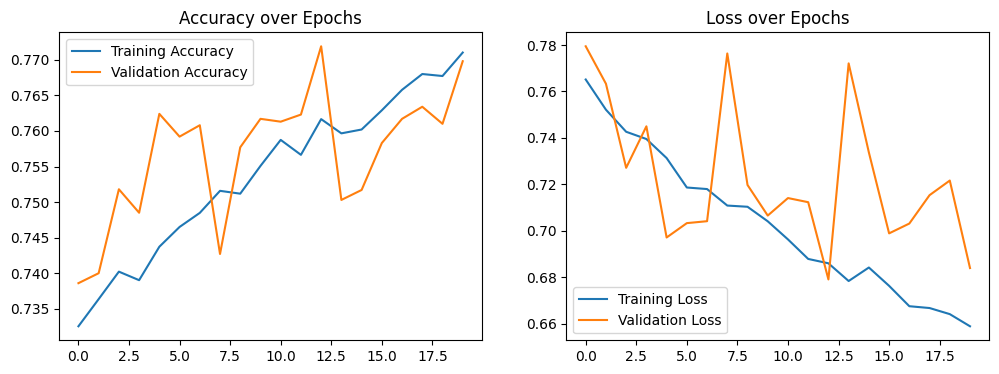

In [ ]:

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.show()

### **selecting sample img**

In [ ]:
img = test_images[0]
img_tensor = np.expand_dims(img, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step


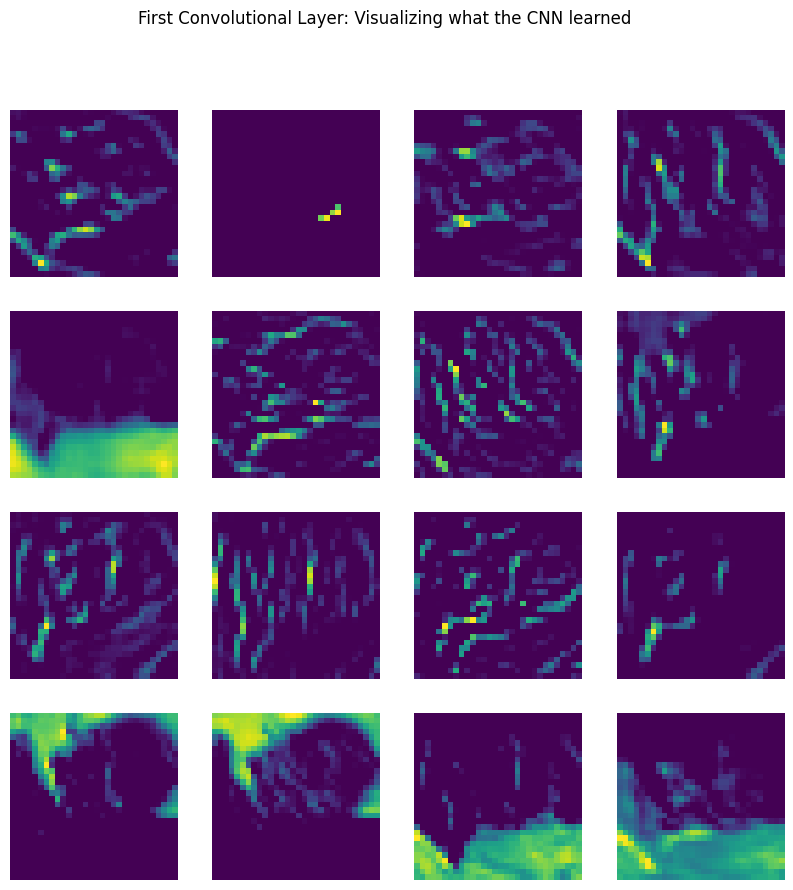

In [ ]:
model.build(input_shape=(None, 32, 32, 3))
sample_img = test_images[0:1] # Shape: (1, 32, 32, 3)

conv_layers = [layer.output for layer in model.layers if 'conv' in layer.name]

viz_model = models.Model(inputs=model.inputs, outputs=conv_layers)
feature_maps = viz_model.predict(sample_img)
first_layer_activations = feature_maps[0]

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i+1)

    plt.imshow(first_layer_activations[0, :, :, i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First Convolutional Layer: Visualizing what the CNN learned")
plt.show()